# RANDOM FORREST PARA ANEGAMIENTO
En este documento voy a aplicar el modelo Random Forrest para predecir las accesiones que a traves de la metodología FIGS sea resistible a anegamiento
# ************************************************************************************************************************************************************

## Importación de librerías ##

In [1]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_recall_curve, roc_curve, classification_report, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
from joblib import dump
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
RANDOM_STATE = 42 # Semilla 
np.random.seed(RANDOM_STATE)

C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carga del dataset. ##

In [2]:
# ============================================
# CARGA DEL DATASET Y EXPLORACIÓN INICIAL
# ============================================

# Cargar dataset
df = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")

# Vista rápida
print("Tamaño del dataset:", df.shape)
print("\nColumnas disponibles:\n", df.columns.tolist())

# Primeras filas
df.head()


Tamaño del dataset: (3357, 67)

Columnas disponibles:
 ['DOI', 'ACCENUMB', 'CURATION', 'GENUS', 'SPECIES', 'GRIN_NAME', 'ORIGCTY', 'COLLSITE', 'DECLATITUDE', 'DECLONGITUDE', 'SAMPSTAT', 'ELEVATION', 'COLLSRC', 'MODCF_CloudForestPrediction', 'MODCF_meanannual', 'MODCF_seasonality_concentration', 'current_30arcsec_annualPET', 'current_30arcsec_aridityIndexThornthwaite', 'current_30arcsec_climaticMoistureIndex', 'current_30arcsec_continentality', 'AWCh1_M_sl1', 'AWCh1_M_sl2', 'AWCtS_M_sl1', 'CECSOL_M_sl1', 'CECSOL_M_sl2', 'CLYPPT_M_sl1', 'CRFVOL_M_sl1', 'BDRICM_M', 'ORCDRC_M_sl1', 'ORCDRC_M_sl2', 'OCDENS_M_sl1', 'OCSTHA_M_sd1', 'PHIHOX_M_sl1', 'PHIKCL_M_sl1', 'BDRLOG_M', 'SNDPPT_M_sl1', 'SLTPPT_M_sl1', 'SLGWRB', 'WWP_M_sl1', 'ACDWRB_M_ss', 'bio1', 'bio10', 'bio12', 'bio13', 'bio14', 'bio15', 'bio18', 'bio19', 'bio2', 'bio3', 'bio8', 'bio9', 'prec_1', 'prec_10', 'prec_11', 'prec_4', 'prec_5', 'prec_6', 'prec_7', 'srad_1', 'srad_10', 'srad_3', 'srad_4', 'srad_5', 'srad_9', 'wind_1', 'wind_1

,DOI,ACCENUMB,CURATION,GENUS,SPECIES,GRIN_NAME,ORIGCTY,COLLSITE,DECLATITUDE,DECLONGITUDE,...,prec_6,prec_7,srad_1,srad_10,srad_3,srad_4,srad_5,srad_9,wind_1,wind_10
0,10.18730/JKECH,G16570,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,KARAJ - MARKAZI,35.81,50.93,...,-1.062011,-1.045993,-1.131852,-0.559309,-0.926190,-0.166400,0.805037,1.113787,-0.158827,0.322904
1,10.18730/JKEKR,G16576,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,KERMANSHAH CHAMCHAL - KERMANSHAH - KERMANSHAHAN,34.32,47.07,...,-1.109707,-1.073673,-1.154124,-0.067053,-0.746152,-0.220326,0.879623,2.107256,-0.372930,0.322904
2,10.18730/JZXX0,G990,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,AHWAZ - KHUZESTAN,31.32,48.70,...,-1.128786,-1.082899,-0.781826,0.306394,-0.175266,0.335804,1.118016,2.205778,0.162328,0.064891
3,10.18730/JZXWU,G989,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,KAZERUN - FARS,29.62,51.63,...,-1.128786,-1.082899,-0.363673,0.921358,0.203504,0.689795,1.501642,2.629266,-0.158827,-0.064115
4,10.18730/JZXT$,G987,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,SHIRAZ - FARS,29.60,52.53,...,-1.119246,-1.073673,-0.417170,1.029527,0.073796,0.454904,1.196261,2.629266,-0.051775,-0.064115


## Validando valores nulos y tipo de variables ##
Después de imprtar el datase se valida si hay valores nulos. También se verifica el tipo de variable de cada columna

In [3]:
# ============================================
# VERIFICAR TIPOS DE VARIABLES Y VALORES NULOS
# ============================================

print("\nTipos de variables:\n", df.dtypes)

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(df.isna().sum().sort_values(ascending=False).head(67))



Tipos de variables:
 DOI          object
ACCENUMB     object
CURATION     object
GENUS        object
SPECIES      object
             ...   
srad_4      float64
srad_5      float64
srad_9      float64
wind_1      float64
wind_10     float64
Length: 67, dtype: object

Valores nulos por columna:
DOI             0
bio8            0
SLTPPT_M_sl1    0
SLGWRB          0
WWP_M_sl1       0
               ..
ORCDRC_M_sl1    0
ORCDRC_M_sl2    0
OCDENS_M_sl1    0
OCSTHA_M_sd1    0
wind_10         0
Length: 67, dtype: int64


## Creando la variable objetivo ##
La variable objetivo se basa en las siguinetes variables bioclimáticas.
* 'bio12',  # Precipitación anual
* 'bio13',  # Precipitación del mes más húmedo
* 'bio14',  # Precipitación del mes más seco
* 'bio15',  # Estacionalidad de la precipitación
* 'bio18',  # Precipitación del trimestre más cálido
* 'bio19',  # Precipitación del trimestre más frío
* 'current_30arcsec_climaticMoistureIndex',  # Índice de humedad climática
* 'current_30arcsec_annualPET',              # Evapotranspiración potencial anual
* 'current_30arcsec_aridityIndexThornthwaite' # Índice de aridez de Thornthwait

In [4]:
# Objetivo: generar 'Resistencia_Anegamiento' mediante clustering ambiental
# Basado en variables de humedad y precipitación
# ============================================================


# Seleccionar variables de humedad y precipitación
variables_humedad = [
    'bio12', 'bio13', 'bio14', 'bio15', 'bio18', 'bio19',
    'current_30arcsec_climaticMoistureIndex',
    'current_30arcsec_annualPET',
    'current_30arcsec_aridityIndexThornthwaite'
]

# Normalización de las variables
scaler = StandardScaler()
scaled = scaler.fit_transform(df[variables_humedad])

# Aplicar K-Means con 3 clusters (seco, intermedio, húmedo)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster_anegamiento"] = kmeans.fit_predict(scaled)

# Identificar el cluster más húmedo según medias de precipitación
means = df.groupby("cluster_anegamiento")[["bio12", "bio13", "bio18"]].mean()
cluster_humedo = means["bio12"].idxmax()
print(f"Cluster más húmedo identificado: {cluster_humedo}")

# Crear variable binaria: 1 = ambiente húmedo (resistente), 0 = demás
df["Resistencia_Anegamiento"] = df["cluster_anegamiento"].apply(
    lambda x: 1 if x == cluster_humedo else 0
)

# Distribución de clases
print(df["Resistencia_Anegamiento"].value_counts(normalize=True) * 100)

# Guardar dataset para modelado
df.to_csv("./dataset_salida/dataset_anegamiento.csv", index=False)
print("Dataset con variable objetivo guardado como 'dataset_anegamiento.csv'")


Cluster más húmedo identificado: 2
Resistencia_Anegamiento
0    82.484361
1    17.515639
Name: proportion, dtype: float64
Dataset con variable objetivo guardado como 'dataset_anegamiento.csv'


## Resultado del cluster ##
El algoritmo K-Means agrupa las accesiones en 3 clusters (0, 1, 2) según las variables de humedad:
* bio12 (precipitación anual)
* bio13 (precipitación del mes más húmedo),
* bio18 (precipitación del trimestre más cálido),

y los índices de humedad/aridez (current_30arcsec_climaticMoistureIndex, etc).

Despues de agrupar calcula el promedio de precipitación dentro de cada grupo y selecciona el que tenga el valor más alto (el más húmedo).
Para mi caso, el cluster 2 representa los ambientes con exceso de humedad o alta pluviosidad.

El resultado:
* 82.5% de las accesiones provienen de ambientes no anegados.
* 17.5% de las acesiones pertenecen a zonas muy húmedas o con exceso de agua.

Con respectopa FIGS, las accesiones que provienen del cluster 2 probablemente pertenecen a regiones con:
* Suelos con drenaje pobre o saturados.
* Precipitación alta durante la mayor parte del año.
* Potencial adaptación fisiológica a anegamiento o suelos húmedos.



## Búsqueda de columnas categoricas ##
Es necesario eliminar las columnas que contienen identificadores ya que el modelo RANDOM_FORRRST no las puede procesar como texto

In [5]:
cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c != "ACCENUMB"]
print("Columnas categóricas detectadas:")
print(cat_cols)

Columnas categóricas detectadas:
['DOI', 'CURATION', 'GENUS', 'SPECIES', 'GRIN_NAME', 'ORIGCTY', 'COLLSITE']


## Codificando columnas de tipo texto ##
Lo que se hace en el siguiente algoritmo es codificar aquellas columnas categoricas. Esto se hace ya que el modelo XGBOOST recibe entradas numéricas.

Desde la perspectiva FIGS, las variables categóricas como:

* GENUS, SPECIES → representan la identidad biológica de cada accesión.

* ORIGCTY → captura la región geográfica macro (proxy del contexto ecológico).

* COLLSITE o ACCENUMB → son metadatos de colecta.

En la práctica FIGS, estos campos no se eliminan, se codifican o se usan como factores de agrupamiento, porque muchas veces los patrones adaptativos tienen un componente geográfico o taxonómico.
Por ejemplo:

* Accesiones de Irán o Afganistán suelen agruparse en ambientes secos → potencial resistencia.

* Accesiones de Brasil o Colombia provienen de climas húmedos → control negativo natural.

Entonces, detectar las variables categóricas  permite decidir cuáles mantener como metadatos (para mapas, interpretación), cuáles incluir codificadas como predictores. Para este acso en especifico solo dejaré la columna ORIGCTY ya que puedo usarla como variable de contexto geográfico.

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


## Eliminar columnas que no se necesitan en el modelo ##
Es necesario eliminar las columnas que contienen identificadores ya que el modelo XGBOOST no las puede procesar como texto

In [7]:
#Variables a eliminar
variables = [
    'bio12',  # Precipitación anual
    'bio13',  # Precipitación del mes más húmedo
    'bio14',  # Precipitación del mes más seco
    'bio15',  # Estacionalidad de la precipitación
    'bio18',  # Precipitación del trimestre más cálido
    'bio19',  # Precipitación del trimestre más frío
    'current_30arcsec_climaticMoistureIndex',  # Índice de humedad climática
    'current_30arcsec_annualPET',              # Evapotranspiración potencial anual
    'current_30arcsec_aridityIndexThornthwaite' # Índice de aridez de Thornthwaite
]

y = df["Resistencia_Anegamiento"]

# Excluir también identificadores y el cluster
exclusiones = ['DOI', 'ACCENUMB', 'cluster_anegamiento', "DECLATITUDE", "DECLONGITUDE",
    "DOI", "ACCENUMB", "CURATION", "GRIN_NAME", "ORIGCTY", 'Resistencia_Anegamiento'] + variables_humedad

X = df.drop(columns=exclusiones )

print(f"Variables predictoras: {X.shape[1]}")
print(f"Total de observaciones: {len(y)}")

Variables predictoras: 51
Total de observaciones: 3357


In [350]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3357 entries, 0 to 3356
Data columns (total 52 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   GENUS                            3357 non-null   int32  
 1   SPECIES                          3357 non-null   int32  
 2   ORIGCTY                          3357 non-null   int32  
 3   COLLSITE                         3357 non-null   int32  
 4   SAMPSTAT                         3357 non-null   float64
 5   ELEVATION                        3357 non-null   float64
 6   COLLSRC                          3357 non-null   float64
 7   MODCF_CloudForestPrediction      3357 non-null   float64
 8   MODCF_meanannual                 3357 non-null   float64
 9   MODCF_seasonality_concentration  3357 non-null   float64
 10  current_30arcsec_continentality  3357 non-null   float64
 11  AWCh1_M_sl1                      3357 non-null   float64
 12  AWCh1_M_sl2         

## División y estratificación ##

In [8]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Tamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)
print("Proporción clases en train:\n", y_train.value_counts(normalize=True))


Tamaño train: (2685, 51)
Tamaño test: (672, 51)
Proporción clases en train:
 Resistencia_Anegamiento
0    0.824953
1    0.175047
Name: proportion, dtype: float64


In [9]:
X_test.to_csv("./dataset_salida/X_test_Random_Forrest_anegamiento.csv", index=False)
y_test.to_csv("./dataset_salida/y_test_Random_Forrest_anegamiento.csv", index=False)

print("Guardado: X_test_Random_Forrest_anegamiento.csv y y_test_Random_Forrest_anegamiento.csv")

Guardado: X_test_Random_Forrest_anegamiento.csv y y_test_Random_Forrest_anegamiento.csv


## Entrenamiento del modelo ##
Entrenamiento del modelo con 80% de los datos para entrenamiento y 20% para prueba. Es importante ya que se garantiza las metricas que refelna le poder predicitivo y no memorización del algoritmo.

Una vez escalado el conjunto de entrenamiento se entrena el modelo a partir de cierto parametros que se pueden configurar de acuerdo a conveniencia.

| Parámetro                  | Qué hace                                                             | Por qué es importante                                                       |
| -------------------------- | -------------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **`n_estimators=500`**     | Número de árboles que se construirán.                                | Cuantos más árboles, mejor estabilidad y menor varianza, hasta que el rendimiento se estabiliza. |
| **`max_depth=None`**       | Profundidad máxima de cada árbol.                                    | Sin limite para que el modelo crezca hasta que converja. Maxima capacidad para aprender                 |
| **`min_samples_split=2`**  | Minimo de muestras necesarias para dividir un nodo.                  | Para este caso, permite dividir mientras haya al menos 2 observaciones.               |
| **`min_samples_leaf=1`**   | Número mínimo de muestras requeridas para formar una hoja terminal.  | Cada hoja puede representar incluso una sola observación.               |
| **`max_features="sqrt"`**  | Cuenta cuántas variabes aleatorias se prueban en cada decisión.      | segura que cada árbol vea combinaciones diferentes de variables climáticas.                 |
| **`class_weight="balanced"`**| Ajusta automáticamente el peso de cada clase según su frecuencia.  | Esto evita que el modelo favorezca la clase mayoritaria y mejora la detección de accesiones resistentes (clase minoritaria).                              |
| **`random_state=RANDM_STATE`**      | Semilla de aleatoriedad.                                             | Garantiza reproducibilidad de los resultados.                               |


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,            # sin límite: el modelo crecerá hasta converger
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",   # compensa clases desbalanceadas
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=500, n_jobs=-1,
                       random_state=42)

## Evaluación del modelo ##
De acuerdo a los resultados se puede identificar que el modelo ha respondido bien, en la siguiente tabla se hace una interpretación de las metricas:

| Métrica             | Valor         | Interpretación                                                                                                                                                                |
| ------------------- | ------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ROC-AUC = 0.997** | **Excelente** | El modelo tiene una capacidad de discriminación casi perfecta: 99.7 % de probabilidad de asignar un puntaje mayor a una accesión resistente frente a una no resistente.       |
| **PR-AUC = 0.986**  | **Excelente** | La precisión promedio se mantiene muy alta incluso cuando el recall disminuye, lo cual es ideal para conjuntos de datos ligeramente desbalanceados.                           |
| **F1 = 0.952**      | **Muy alto**  | Existe un equilibrio sólido entre precisión y recall. Esto indica que el modelo logra una predicción muy consistente, con bajo número de falsos positivos y falsos negativos. |

## Reporte de la clasificación ##
Para la clase 0 que representa las Accesiones No Resitentes, la precisión es de 0.98 lo que significa que de cada 100 accesiones predichas como no resistentes, 98 realmente no lo son.

El Recall es de 1.00 esto significa que todas las accesiones no resistentes reales, el modelo detecta correctamente el 100 %.

Para la clase 1 que representa las accesiones resistentes, la precisión es de 0.98 lo que indica que de cada 100 predichas como resistentes, 98 son verdaderamente resistentes.

El Recall es de 0.91, esto significa que de todas las accesiones resistentes reales, el modelo acierta el 91 %.

Lo anterior demuestra que el modelo no presenta un sesgo fuerte hacia ninguna clase.

En contextos biológicos, en este caso la resistencia  la sequía, este equilibrio es ideal porque los falsos negativos (accesiones resistentes no detectadas) y falsos positivos (no resistentes mal clasificados) son ambos costosos.



In [11]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, confusion_matrix
)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_proba)
pr  = average_precision_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)

print(f"ROC-AUC: {roc:.3f}")
print(f"PR-AUC:  {pr:.3f}")
print(f"F1:      {f1:.3f}\n")

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))


ROC-AUC: 0.997
PR-AUC:  0.986
F1:      0.952

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       554
           1       0.98      0.92      0.95       118

    accuracy                           0.98       672
   macro avg       0.98      0.96      0.97       672
weighted avg       0.98      0.98      0.98       672


Matriz de confusión:
[[552   2]
 [  9 109]]


## Matriz de confusión ##
|                             | Predicción: No resistente | Predicción: Resistente |
| --------------------------- | ------------------------- | ---------------------- |
| **Real: No resistente (0)** | **552** (VP)              | **02** (FP)            |
| **Real: Resistente (1)**    | **11** (FN)               | **107** (VP)           |

El modelo comete errores pequenos en la predicción, esto explica prque la exactitud es del 93%.

Para FIGS, El modelo distingue bien entre ambientes o características de accesiones resistentes vs. no resistentes.


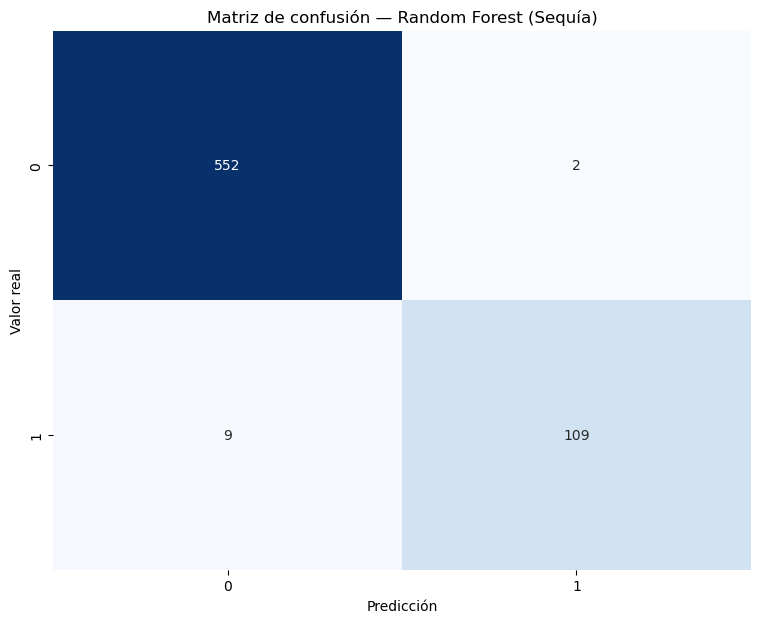

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Usa las predicciones con el umbral que elijas (por ejemplo, pred_best o pred05)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión — Random Forest (Sequía)')
plt.show()


## Importancia de las variables ##

El promedio de reducción de impureza (Gini) calcula la importancia de las variables en la predicción. Entre mas grande sea la reducción media de una variable, mayor es su importancia.

Se puede observar que el modelo aprendió patrones climáticos robustos relacionados con la disponibilidad de agua y radiación. Estas variables, **bio15, bio19, y bio14** (precipitaciones estacionales y extremas) definen el gradiente principal de sequía. Variables como la radiación (srad_*) y nube MODCF complementan el efecto energético, ajustando la capacidad adaptativa de las accesiones. Esto permite identificar que la resistencia a sequía está asociada tanto a la variabilidad hídrica como a la radiación incidente (efecto combinado energía–agua).

Desde lo biologico se puede interpretar que:

| Variable                                                                   | Descripción ecológica                                                            | Interpretación en contexto de anegamiento                                                                                                                                |
| -------------------------------------------------------------------------- | -------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **prec_10 – Precipitación de octubre**                                     | Representa el inicio de la temporada lluviosa en gran parte de América tropical. | Alta importancia ya que los ambientes con fuertes lluvias en octubre favorecen la selección natural de accesiones con mecanismos de tolerancia a suelos saturados o anegados. |
| **prec_11 – Precipitación de noviembre**                                   | Precipitaciones de final de año.                                                 | Refleja ambientes con exceso hídrico prolongado tras varios meses de lluvias, ideal para distinguir materiales adaptados a drenaje deficiente.                          |
| **prec_5 – Precipitación de mayo**                                         | Marca el establecimiento de la primera estación húmeda.                          | Las accesiones resistentes provienen de zonas donde mayo concentra altos volúmenes de precipitación, generando condiciones de anegamiento en suelos planos o arcillosos. |
| **prec_4 – Precipitación de abril**                                        | Lluvias de transición entre estación seca y húmeda.                              | Influye en la capacidad de germinación y establecimiento bajo suelos con saturación temprana.                                                                            |
| **prec_6 – Precipitación de junio**                                        | Lluvias medias de mitad de año.                                                  | Contribuye a mantener la humedad del suelo; los genotipos resistentes soportan periodos prolongados de encharcamiento.                                                   |
| **prec_7 – Precipitación de julio**                                        | Pico de la estación húmeda.                                                      | Ambientes con exceso hídrico sostenido durante julio presionan la selección de accesiones con tolerancia fisiológica al anoxia radicular.                                |
| **PHIHOX_M_sl1 – pH del suelo (horizonte superficial)**                    | Acidez o alcalinidad del suelo.                                                  | El pH modula la disponibilidad de oxígeno y nutrientes bajo anegamiento; valores extremos agravan el estrés y favorecen adaptaciones morfofisiológicas.                  |
| **PHIKCL_M_sl1 – pH en KCl (horizonte superficial)**                       | Medida del pH efectivo en solución.                                              | Indica la capacidad tampón del suelo. Suelos con pH moderado permiten una mejor recuperación tras eventos de inundación.                                                 |
| **AWCTSL_M_sl1 – Capacidad de retención de agua (0–5 cm)**                 | Capacidad del suelo para almacenar humedad.                                      | Alta importancia → los suelos con alta retención tienden a saturarse más fácilmente, lo que genera presión selectiva hacia genotipos tolerantes a hipoxia.               |
| **prec_1 – Precipitación de enero**                                        | Representa condiciones húmedas tempranas.                                        | Accesiones adaptadas a lluvias fuera de temporada podrían tener tolerancia basal a suelos encharcados.                                                                   |
| **MODCF_seasonality_concentration – Variabilidad estacional de nubosidad** | Mide los cambios en cobertura nubosa a lo largo del año.                         | Regula la radiación solar y evapotranspiración: una nubosidad persistente favorece microclimas húmedos y prolonga el anegamiento.                                        |
| **MODCF_meanannual – Cobertura nubosa media anual (MODIS)**                | Promedio de cobertura de nubes a lo largo del año.                               | Alta nubosidad reduce la evaporación, incrementando la duración de la saturación del suelo.                                                                              |
| **ORCDRC_M_sl2 – Contenido de materia orgánica (horizonte 5–15 cm)**       | Indicador de fertilidad y capacidad de retención de agua.                        | Suelos con alto contenido orgánico retienen más humedad y presentan mayor riesgo de anoxia, impulsando adaptaciones fisiológicas en la raíz.                             |
| **bio2 – Amplitud térmica media diaria (°C)**                              | Diferencia media entre temperaturas máximas y mínimas diarias.                   | Una baja amplitud térmica suele acompañar ambientes húmedos con alta cobertura nubosa y suelos saturados.                                                                |
| **ORIGCTY – Código de procedencia geográfica**                             | Variable categórica que agrupa regiones de origen.                               | Ayuda a distinguir ambientes geográficos donde el exceso hídrico es un factor selectivo (ej. regiones costeras, valles con drenaje deficiente).                          |



In [14]:
importances = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importances.head(15)


,Variable,Importancia
37,prec_10,0.136858
38,prec_11,0.105176
40,prec_5,0.104874
39,prec_4,0.074195
41,prec_6,0.054101
42,prec_7,0.045862
22,PHIHOX_M_sl1,0.042076
12,AWCtS_M_sl1,0.035275
23,PHIKCL_M_sl1,0.028756
8,MODCF_seasonality_concentration,0.026870


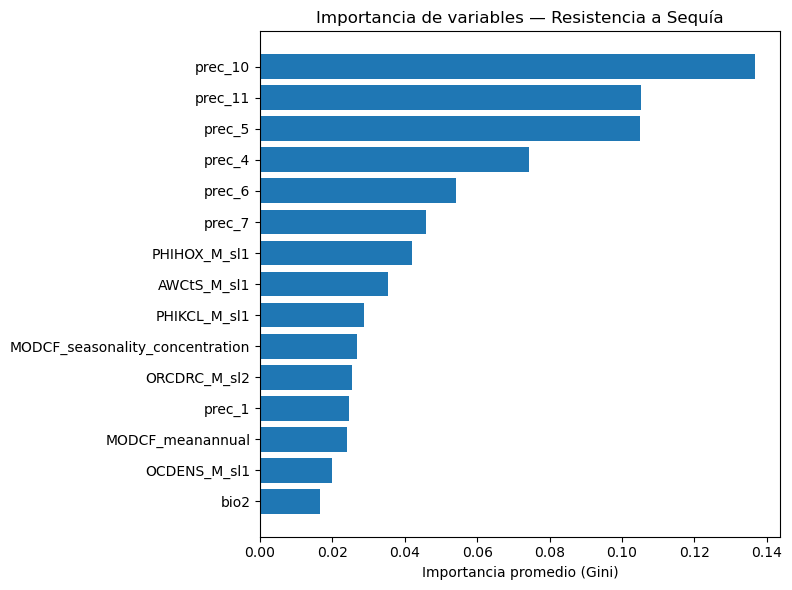

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(importances["Variable"].head(15),
         importances["Importancia"].head(15))
plt.gca().invert_yaxis()
plt.title("Importancia de variables — Resistencia a Sequía")
plt.xlabel("Importancia promedio (Gini)")
plt.tight_layout()
plt.show()


| Tipo de variable dominante           | Ejemplo principal                                     | Rol ecológico en resistencia al anegamiento                                                                                                                                                                   |
| ------------------------------------ | ----------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Precipitación (mensual)**          | prec_10, prec_5, prec_11, prec_4                      | Controla la magnitud y duración de los periodos de saturación del suelo. Altas lluvias continuas generan condiciones de hipoxia radicular y favorecen la selección de genotipos tolerantes al exceso de agua. |
| **Propiedades del suelo (edáficas)** | PHIH0X_M_sl1, PHIKCL_M_sl1, AWCTS_M_sl1, ORCDRC_M_sl2 | Determinan la capacidad de drenaje, pH y retención de humedad del suelo. Suelos con alta retención o baja aireación intensifican el estrés por anegamiento.                                                   |
| **Nubosidad (MODCF)**                | MODCF_meanannual, MODCF_seasonality_concentration     | Regula la radiación y evapotranspiración. Una cobertura nubosa persistente prolonga el encharcamiento y reduce el secado del suelo.                                                                           |
| **Temperatura (BIO)**                | bio2                                                  | Influye en la tasa metabólica y en la capacidad de las plantas para tolerar bajas concentraciones de oxígeno en raíces. Ambientes húmedos suelen tener amplitudes térmicas menores.                           |
| **Origen geográfico (ORIGCTY)**      | ORIGCTY                                               | Refleja regiones con patrones climáticos húmedos (ej. Chocó, Amazonía, Caribe). Indica posible presión selectiva por exceso hídrico.                                                                          |


## Curva ROC y Precisión Recall ##
La curva ROC compara la tasa de verdaderos positivos (TPR o sensibilidad) con la tasa de falsos positivos (FPR) a medida que se varía el umbral de decisión (threshold).

Interpretación visual:

* La línea diagonal (gris) representa un clasificador aleatorio (AUC = 0.5).
* El modelo está por encima de esta linea lo que significa que distingue muy bien entre accesiones resistentes y no resistentes.
* AUC = 0.997

Esto significa que si se escoge una accesión resistente y una no resistente al azar, el modelo tiene un 99 % de probabilidad de asignar mayor score a la resistente.

## Curva precisión-Recall ##

Evalúa el equilibrio entre precisión y recuperación (recall), La curva se mantiene muy alta (> 0.9) en casi todo el rango de recall, el modelo mantiene alta precisión incluso cuando intenta recuperar muchos positivos.

* La caída final cerca de recall = 1 indica los últimos umbrales, donde se empieza a sobreclasificar (más falsos positivos).
* PR-AUC = 0.986 es un excelnte rendimiento lo que indica que el modelo equilibra precisión y sensibilidad de forma óptima.

Desde la parte biológica, el comportamiento (AUC > 0.997 y PR-AUC > 0.986) significa que el espacio climático definido por las variables importantes (precipitación estacional, radiación, temperatura) separa claramente los ambientes donde las accesiones han evolucionado resistencia a sequía.

En términos de adaptación, las accesiones resistentes ocupan un nicho ecológico bien diferenciado, las variables climáticas seleccionadas capturan de forma muy precisa ese gradiente ambiental.

Para FIGS (Focus Identification of Germplasm Strategy), el resultado anterior indica que el modelo tiene alta capacidad predictiva para seleccionar nuevas accesiones candidatas con potencial de resistencia, sin necesidad de ensayos de campo extensivos.

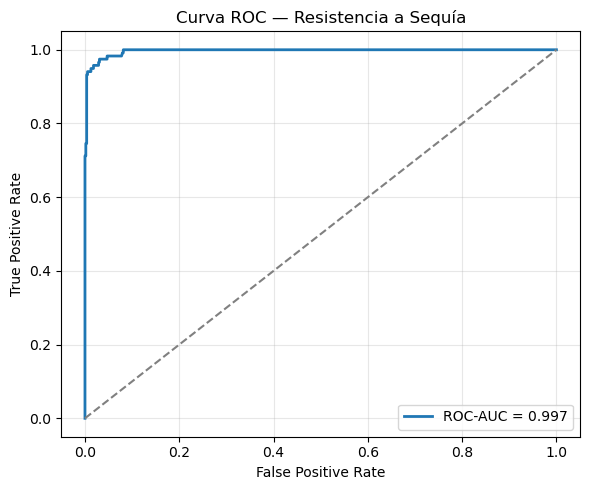

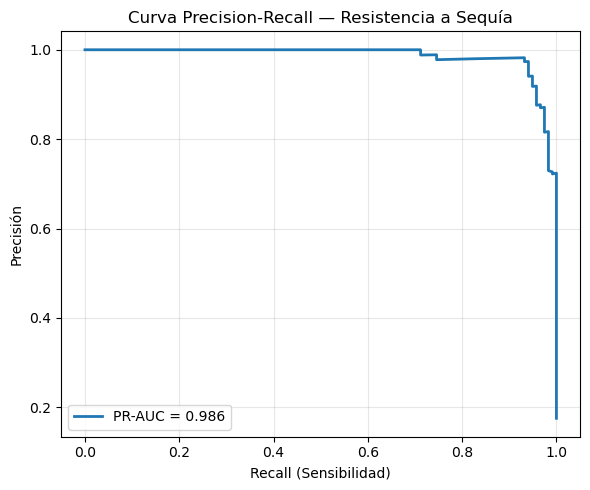

In [16]:
# Curva ROC y RECALL
from sklearn.metrics import roc_curve, precision_recall_curve

# Probabilidades predichas (ya las tenemos)
y_proba = rf.predict_proba(X_test)[:, 1]

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba):.3f}", lw=2)
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Resistencia a Sequía")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, y_proba):.3f}", lw=2)
plt.xlabel("Recall (Sensibilidad)")
plt.ylabel("Precisión")
plt.title("Curva Precision-Recall — Resistencia a Sequía")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Prueba del algoritmo ##

In [17]:
# ==========================================
# Predicción para accesión G23703 (La Guajira)
# ==========================================
import pandas as pd

choco = pd.DataFrame({
    "bio15": [20],   # Estacionalidad baja (lluvias todo el año)
    "srad_10": [14000],  # Radiación baja por nubosidad persistente
    "bio19": [1800],  # Precipitación trimestre más frío (mm)
    "bio2": [6.5],    # Amplitud térmica muy baja (clima estable y húmedo)
    "prec_4": [450],  # Alta precipitación mensual (abril)
    "bio1": [26],     # Temperatura media anual (~26°C)
    "MODCF_meanannual": [0.85],  # Alta nubosidad media anual (85%)
    "srad_3": [14500],  # Radiación moderada (por nubes)
    "bio14": [250],   # Mes más seco aún con lluvia abundante
    "bio8": [26.5],   # Temp. media trimestre más húmedo
    "MODCF_seasonality_concentration": [0.15],  # Variabilidad nubosa baja
    "srad_4": [14200],  # Radiación de abril
    "prec_11": [480],  # Lluvias muy altas en noviembre
    "srad_1": [15000],  # Radiación enero
    "bio10": [27]      # Temp. media trimestre más cálido
}, index=["G11067_Choco"])


# Asegurar orden de columnas igual al modelo
choco = choco.reindex(columns=X.columns, fill_value=0)

# Predicciones
p_anegamiento = rf.predict_proba(choco)[0,1]


print("Accesión: G11067 (Chocó)")
print(f"Prob. resistencia a anegamiento: {p_anegamiento:.3f}")
print("Clasificación anegamiento:", "Resistente" if p_anegamiento>=0.7 else "No resistente")


Accesión: G11067 (Chocó)
Prob. resistencia a anegamiento: 0.244
Clasificación anegamiento: No resistente


##  Coherencia del modelo a partir del gradiente ##
Realizada la aprueba anterior, el resultado no es lo esperado, se puede inferir que a pesar de ser colectada en una zona desertica, las condicones ambientales no son suficientes para ser una candidata a sequía. Aquí, se utiliza la coherencia del modelo a partir del gradiente que permite ver las accesiones con mayor probabilidad a sequía.

In [18]:
df["p_anegamiento"] = rf.predict_proba(X)[:, 1]

# Unir con una copia del dataframe original sin codificar
df_pred = df[["ACCENUMB"]].copy()
df_pred["p_anegamiento"] = df["p_anegamiento"]

# Mostrar el top 10
df_pred.sort_values("p_anegamiento", ascending=False).head(10)

,ACCENUMB,p_anegamiento
1803,G8192,1.0
1908,G50892,1.0
1850,G51645C,1.0
2000,G24704,1.0
1918,G50876,1.0
1916,G50877,1.0
1862,G51456,1.0
1863,G51457,1.0
2018,G24006,1.0
2036,G22146,1.0


## Distribución de probabilidad a anegamiento en el modelo ##
Se puede observar que el modelo distingue de forma clara los ambientes aridos vs húmedos. La curva que se obtien es bimodal, con dos picos muy marcados lo que indica que el modelo distingue dos grupos climáticos bien definidos, lo que demuestra una alta separabilidad del gradiente climático. Esto es muy bueno porque me permite confirmar que el modelo aprendió correctamente el “eje ambiental FIGS”: desde ambientes húmedos hasta ambientes áridos con estrés hídrico.

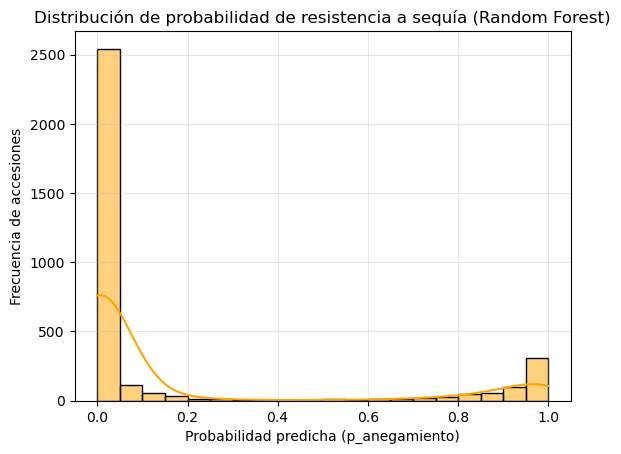

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["p_anegamiento"], bins=20, kde=True, color="orange")
plt.title("Distribución de probabilidad de resistencia a sequía (Random Forest)")
plt.xlabel("Probabilidad predicha (p_anegamiento)")
plt.ylabel("Frecuencia de accesiones")
plt.grid(alpha=0.3)
plt.show()


## Condiciones para probar el algoritmo ##
Se escoge una Accesión que se considera cumpla las condiciones ambientales para ser resistente a anegamiento. Estos datos se obtiene del dataset y se deben ordenar y codificar las mismas columnas de la forma en como se entreno el algoritmo.

In [20]:
cols_modelo = X.columns  # las columnas originales con las que entrenaste

accesion_number = (
    df[df["ACCENUMB"] == "G50382"]
    .drop(columns=[
        "bio12", 
        "bio13",  
        "bio14",  
        "bio15",  
        "bio18", 
        "bio19",  
        "current_30arcsec_climaticMoistureIndex", 
        "current_30arcsec_annualPET",              
        "current_30arcsec_aridityIndexThornthwaite",
        "DECLATITUDE", "DECLONGITUDE","DOI", "ACCENUMB", "CURATION", "GRIN_NAME", "cluster_anegamiento", "Resistencia_Anegamiento",
        "p_anegamiento"  # <-- importante eliminar
    ], errors="ignore")  # evita error si alguna no existe
)
cat_cols = accesion_number.select_dtypes(include=['object']).columns.tolist()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    accesion_number[col] = le.fit_transform(df[col].astype(str))

# Verifica columnas
print(set(accesion_number.columns) - set(cols_modelo))
# Reordena las columnas para que coincidan con el modelo
G50382 = accesion_number[cols_modelo]

# Predice
p_anegamiento = rf.predict_proba(G50382)[0,1]
print(f"Probabilidad de resistencia a anegamiento: {p_anegamiento:.3f}")


{'ORIGCTY'}
Probabilidad de resistencia a anegamiento: 1.000


In [22]:
# ============================================================
# GUARDAR Y CARGAR MODELO RANDOM FOREST
import joblib

# Guardar modelo entrenado
joblib.dump(rf, "./best_model/randomforest_anegamiento_model.pkl")
print("Modelo Random Forest (sequía) guardado como 'randomforest_anegamiento_model.pkl'")

# --- Para cargarlo después ---
#rf_loaded = joblib.load("randomforest_anegamiento_model.pkl")
#print("Modelo Random Forest cargado correctamente y listo para predecir.")

Modelo Random Forest (sequía) guardado como 'randomforest_anegamiento_model.pkl'


##  Asociando probabilidades con accesiones ##

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [9]:
import joblib
rf = joblib.load("./best_model/randomforest_anegamiento_model.pkl")

In [10]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]


In [11]:
ACCENUMB_test = df.loc[X_test.index, "ACCENUMB"]

In [14]:
df_rf_pred = pd.DataFrame({
    "ACCENUMB": ACCENUMB_test.values,
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_proba": y_proba,
    "modelo": "RandomForest",
    "problema": "Anegamiento"
})


In [15]:
df_rf_pred.to_csv("./dataset_salida/predicciones_rf_anegamiento.csv", index=False)
print("Archivo creado: predicciones_rf_anegamiento.csv")


Archivo creado: predicciones_rf_anegamiento.csv


In [16]:
df_env = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")

df_rf_sequia_completo = df_rf_pred.merge(
    df_env, on="ACCENUMB", how="left"
)

df_rf_sequia_completo.to_csv("./dataset_salida/rf_anegamiento.csv", index=False)
print("Archivo listo: rf_anegamiento.csv")


Archivo listo: rf_anegamiento.csv
